In [1]:
from google.colab import files

In [2]:
uploaded=files.upload()

Saving smart_logistic_cleanead.csv to smart_logistic_cleanead.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [4]:
df= pd.read_csv('smart_logistic_cleanead.csv')

In [5]:
df

,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Logistics_Delay_Reason,Asset_Utilization,Demand_Forecast,Logistics_Delay,Date
0,2024-03-20 00:11:14,Truck_7,-65.7383,11.2497,390,Delayed,27.0,67.8,Detour,38,320,4,NaN,60.1,285,1,2024-03-20
1,2024-10-30 07:53:51,Truck_6,22.2748,-131.7086,491,In Transit,22.5,54.3,Heavy,16,439,7,Weather,80.9,174,1,2024-10-30
2,2024-07-29 18:42:48,Truck_10,54.9232,79.5455,190,In Transit,25.2,62.2,Detour,34,355,3,NaN,99.2,260,0,2024-07-29
3,2024-10-28 00:50:54,Truck_9,42.3900,-1.4788,330,Delivered,25.4,52.3,Heavy,37,227,5,Traffic,97.4,160,1,2024-10-28
4,2024-09-27 15:52:58,Truck_7,-65.8477,47.9468,480,Delayed,20.5,57.2,Clear,56,197,6,NaN,71.6,270,1,2024-09-27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2024-07-22 16:30:00,Truck_6,89.8701,73.6867,264,Delivered,26.9,70.0,Heavy,32,188,1,Weather,79.2,213,1,2024-07-22
996,2024-04-30 04:58:58,Truck_5,-10.4792,-177.1239,479,Delivered,23.7,77.9,Detour,56,276,7,Weather,83.7,272,0,2024-04-30
997,2024-10-27 22:09:13,Truck_2,-71.0609,75.3714,347,In Transit,21.0,63.1,Detour,35,382,5,NaN,74.8,275,0,2024-10-27
998,2024-04-18 23:06:56,Truck_2,-76.7910,18.3631,276,Delivered,18.0,64.3,Heavy,10,361,5,NaN,88.6,242,1,2024-04-18


## Data cleaning
 we are about to clean a logistics 1000 rows and 17 columns  dataset

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Timestamp                1000 non-null   object 
 1   Asset_ID                 1000 non-null   object 
 2   Latitude                 1000 non-null   float64
 3   Longitude                1000 non-null   float64
 4   Inventory_Level          1000 non-null   int64  
 5   Shipment_Status          1000 non-null   object 
 6   Temperature              1000 non-null   float64
 7   Humidity                 1000 non-null   float64
 8   Traffic_Status           1000 non-null   object 
 9   Waiting_Time             1000 non-null   int64  
 10  User_Transaction_Amount  1000 non-null   int64  
 11  User_Purchase_Frequency  1000 non-null   int64  
 12  Logistics_Delay_Reason   737 non-null    object 
 13  Asset_Utilization        1000 non-null   float64
 14  Demand_Forecast          

In [7]:
df.columns

Index(['Timestamp', 'Asset_ID', 'Latitude', 'Longitude', 'Inventory_Level',
       'Shipment_Status', 'Temperature', 'Humidity', 'Traffic_Status',
       'Waiting_Time', 'User_Transaction_Amount', 'User_Purchase_Frequency',
       'Logistics_Delay_Reason', 'Asset_Utilization', 'Demand_Forecast',
       'Logistics_Delay', 'Date'],
      dtype='object')

In [8]:
df.fillna('No reason',inplace=True)

In [12]:
delayed_df=df[df['Shipment_Status']=='Delayed']

In [13]:
df['Timestamp']=pd.to_datetime(df['Timestamp'])
df['Date']=pd.to_datetime(df['Date'])

## EDA EXPLOARATORY

In [14]:
df.describe()

,Timestamp,Latitude,Longitude,Inventory_Level,Temperature,Humidity,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Asset_Utilization,Demand_Forecast,Logistics_Delay,Date
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000
mean,2024-06-30 23:15:56.539000064,-1.360093,0.837049,297.915000,23.893900,65.042200,35.062000,299.055000,5.513000,79.599100,199.284000,0.566000,2024-06-30 11:13:55.200000
min,2024-01-01 11:37:57,-89.791500,-179.820200,100.000000,18.000000,50.000000,10.000000,100.000000,1.000000,60.000000,100.000000,0.000000,2024-01-01 00:00:00
25%,2024-03-27 01:27:56.500000,-46.167975,-88.448075,201.000000,21.200000,57.200000,23.000000,191.750000,3.000000,69.475000,144.000000,0.000000,2024-03-26 18:00:00
50%,2024-07-01 03:30:16.500000,-4.503150,0.678300,299.000000,23.800000,65.200000,35.000000,301.500000,6.000000,79.250000,202.000000,1.000000,2024-06-30 12:00:00
75%,2024-10-02 13:30:34.500000,44.502800,88.156450,399.000000,26.600000,72.400000,49.000000,405.000000,8.000000,89.425000,251.250000,1.000000,2024-10-02 00:00:00
max,2024-12-30 20:21:58,89.870100,179.923700,500.000000,30.000000,80.000000,60.000000,500.000000,10.000000,100.000000,300.000000,1.000000,2024-12-30 00:00:00
std,NaN,51.997183,104.843618,113.554773,3.322178,8.753765,14.477768,117.787792,2.935379,11.631153,59.920847,0.495873,NaN


In [15]:
df.corr(numeric_only=True)

,Latitude,Longitude,Inventory_Level,Temperature,Humidity,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Asset_Utilization,Demand_Forecast,Logistics_Delay
Latitude,1.000000,-0.000504,0.014807,-0.018829,-0.030202,-0.025667,-0.035171,0.003924,-0.023606,0.022109,0.039634
Longitude,-0.000504,1.000000,-0.023186,0.007388,0.031622,0.031938,-0.019753,-0.036788,0.002916,0.098412,0.011796
Inventory_Level,0.014807,-0.023186,1.000000,-0.021061,0.013395,-0.020337,-0.036785,-0.019701,0.017041,-0.016727,-0.003340
Temperature,-0.018829,0.007388,-0.021061,1.000000,-0.022674,0.017392,-0.006377,-0.017139,0.046005,-0.010425,-0.038067
Humidity,-0.030202,0.031622,0.013395,-0.022674,1.000000,0.029030,-0.034828,0.023341,-0.030637,-0.005887,-0.000504
Waiting_Time,-0.025667,0.031938,-0.020337,0.017392,0.029030,1.000000,-0.017796,0.023582,0.018008,-0.030042,-0.063036
User_Transaction_Amount,-0.035171,-0.019753,-0.036785,-0.006377,-0.034828,-0.017796,1.000000,0.038406,0.038607,0.004531,0.013605
User_Purchase_Frequency,0.003924,-0.036788,-0.019701,-0.017139,0.023341,0.023582,0.038406,1.000000,0.024445,-0.082900,-0.017439
Asset_Utilization,-0.023606,0.002916,0.017041,0.046005,-0.030637,0.018008,0.038607,0.024445,1.000000,-0.077926,-0.003140
Demand_Forecast,0.022109,0.098412,-0.016727,-0.010425,-0.005887,-0.030042,0.004531,-0.082900,-0.077926,1.000000,-0.018621


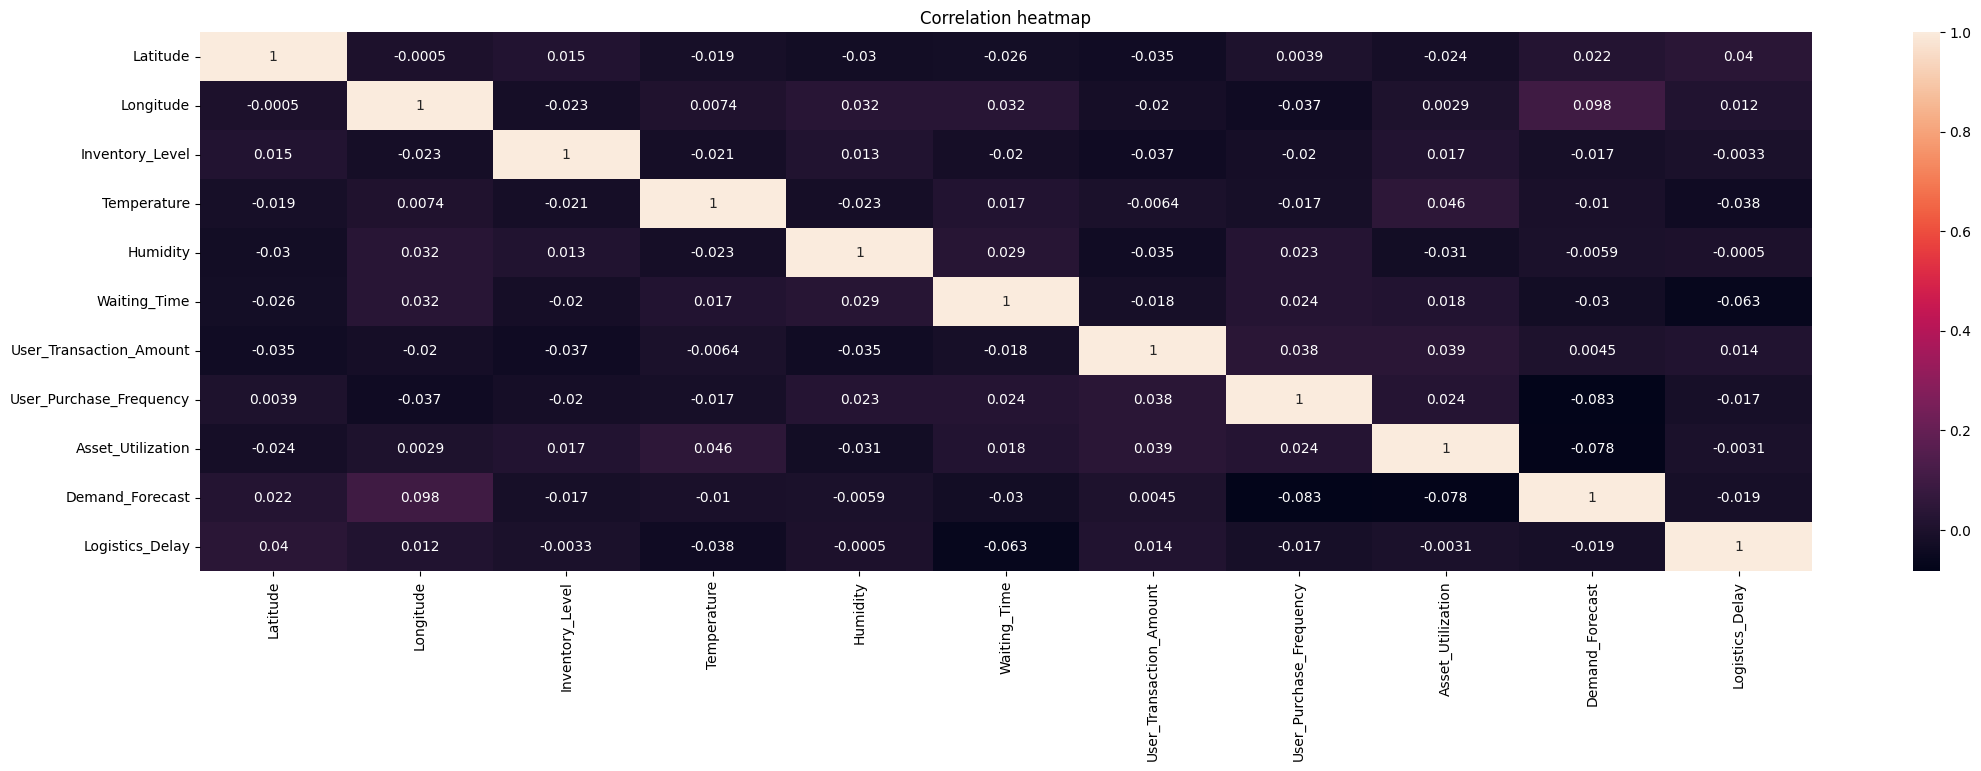

In [18]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.rcParams['figure.figsize']=(26,7)
plt.title('Correlation heatmap')
plt.show()

As we can see value are not realy correlated(talking about only numeric values

In [19]:
Total_shipment_by_Asset=df['Asset_ID'].value_counts()

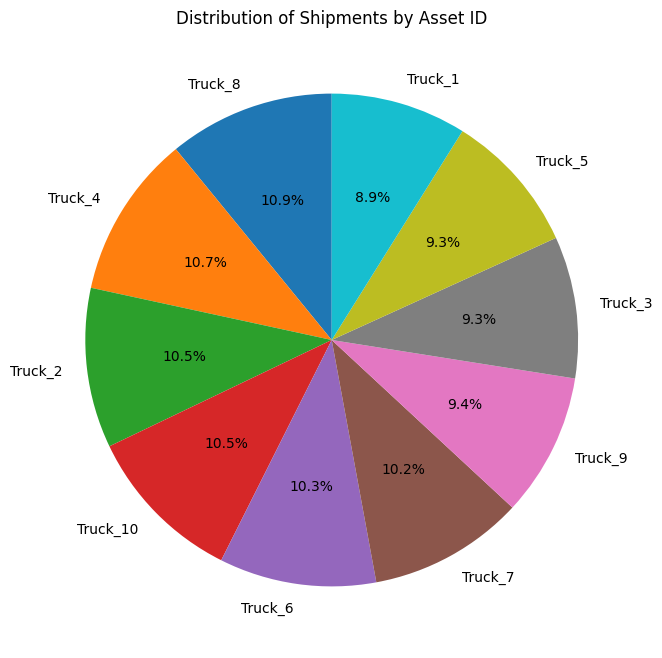

In [20]:
plt.figure(figsize=(8,8))
plt.pie(Total_shipment_by_Asset,labels=Total_shipment_by_Asset.index,autopct='%1.1f%%',startangle=90)
plt.title('Distribution of Shipments by Asset ID')
plt.show()

# shipment distribution by asset
* truck 8 made 10.9% of the shipment
* truck 4 made 10.7% of the shipment
* truck 2 made 10.5% of the shipment
* truck 10 made 10.5% of the shipment
* truck 3 made 9.3% of the shipment
* truck 6 made 10.3% of the shipment
* truck 7 made 10.2% of the shipment
* truck 9 made 9.4% of the shipment
* truck 5 made 9.3% of the shipment
* truck 1 made 8.9% of the shipment





In [21]:
# creating the month column
df['Month']=df['Date'].dt.month

In [22]:
shipment_evolution_by_Asset=df[['Month']].sort_index(ascending=True).value_counts()
shipment_evolution_by_Asset=shipment_evolution_by_Asset.reset_index()

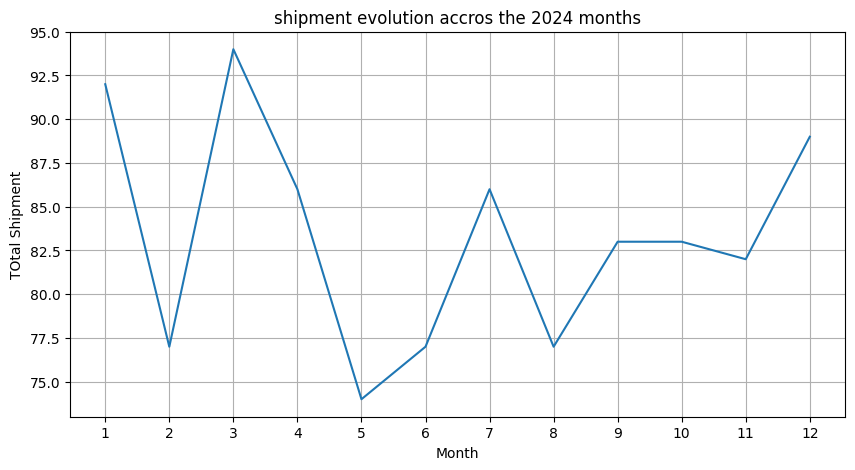

In [23]:
plt.figure(figsize=(10, 5))
sns.lineplot(shipment_evolution_by_Asset,x='Month',y='count')
plt.xticks(range(1,13))
plt.ylabel('TOtal Shipment')
plt.title('shipment evolution accros the 2024 months')
plt.grid(True)
plt.show()


## shipment evolution with  months

* From january to february the shipment dramastically fell from more than 90 shipment in january to less than 77 shipment in february


* From february to March the shipment  jumped from less than 77 shipment in february  to more than 92 shipment in march

* From March to may the shipment  fell down from more than 92 shipment in March passing by a small in diminution in April less than 87 to less than 75 shipment in may



* From May to july  the shipment  jumped from less than 75 shipment in may  by also passing by a small evolution in june more than 77 shipment  to more than 85 shipment in july

* From july to august the shipment  jumped from more than 85 shipment in july  to less than 77 shipment in august

* From August to september the shipment  jumped from less than 77 shipment in august  to more than 82 shipment in september

* From September to november the shipment was relatively constant around 82 shipment


* From november  to december  the shipment  jumped from around than 82 shipment in november  to more than 87 shipment in december


we can conclude that the minimun shipement  was in februarary, may AUgust and the maximum was in January, March,July and december

In [24]:
shipment_status_by_asset=df[['Asset_ID','Shipment_Status']].groupby(['Asset_ID','Shipment_Status']).value_counts()

In [25]:
shipment_status_by_asset=shipment_status_by_asset.reset_index()

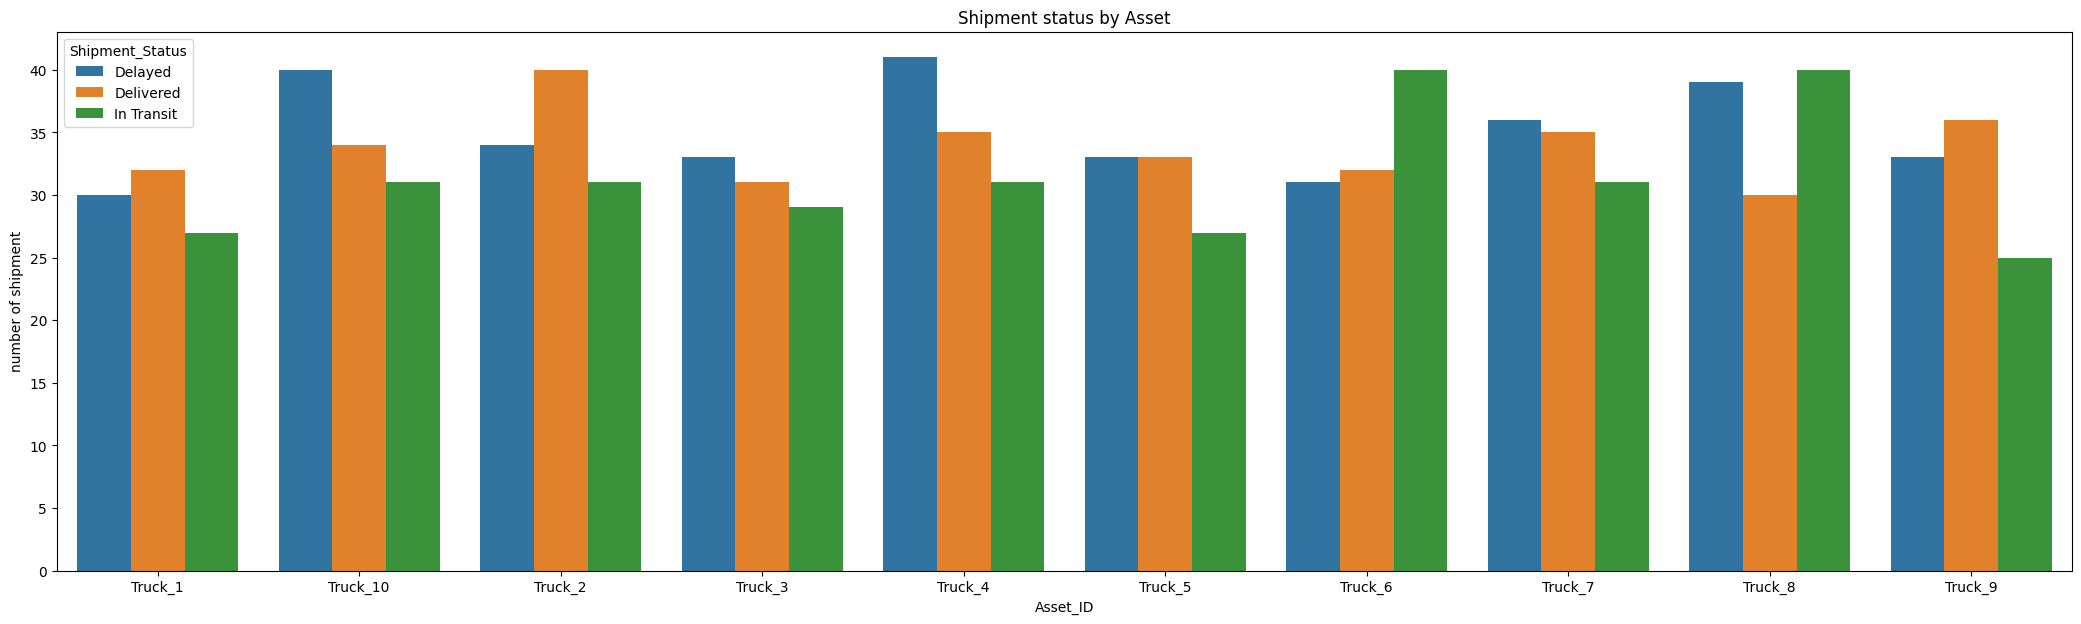

In [26]:
sns.barplot(shipment_status_by_asset,x='Asset_ID',hue='Shipment_Status',y='count')
plt.rcParams['figure.figsize']=(20,7)
plt.title('Shipment status by Asset')
plt.ylabel('number of shipment')
plt.show()

In [27]:
status_pct = pd.crosstab(
    df['Asset_ID'],
    df['Shipment_Status'],
    normalize='index'
) * 100

In [28]:
status_pct

Shipment_Status,Delayed,Delivered,In Transit
Asset_ID,,,
Truck_1,33.707865,35.955056,30.337079
Truck_10,38.095238,32.380952,29.523810
Truck_2,32.380952,38.095238,29.523810
Truck_3,35.483871,33.333333,31.182796
Truck_4,38.317757,32.710280,28.971963
Truck_5,35.483871,35.483871,29.032258
Truck_6,30.097087,31.067961,38.834951
Truck_7,35.294118,34.313725,30.392157
Truck_8,35.779817,27.522936,36.697248


### shipment status by asset

* truck1: 35.96% of the shipment was delivered,33.71% was  delayed and 30.34% was in transit
* truck2: 38.10% of the shipment was delivered,32.38% was  delayed and 29.52% was in transit
* truck3: 33.33% of the shipment was delivered,35.48% was  delayed and 31.18% was in transit
* truck4: 32.71% of the shipment was delivered,38.32% was  delayed and 28.97% was in transit
* truck5: 35.48% of the shipment was delivered,35.48% was  delayed and 29.03% was in transit
* truck6: 31.07% of the shipment was delivered,30.10% was  delayed and 38.83% was in transit
* truck7: 34.31% of the shipment was delivered,35.29% was  delayed and 30.39% was in transit
* truck8: 27.52% of the shipment was delivered,35.78% was  delayed and 36.70% was in transit
* truck9: 38.30% of the shipment was delivered,3511% was  delayed and 26.60% was in transit
* truck10: 32.38% of the shipment was delivered,38.10% was  delayed and 29.52% was in transit

<Axes: xlabel='Shipment_Status', ylabel='count'>

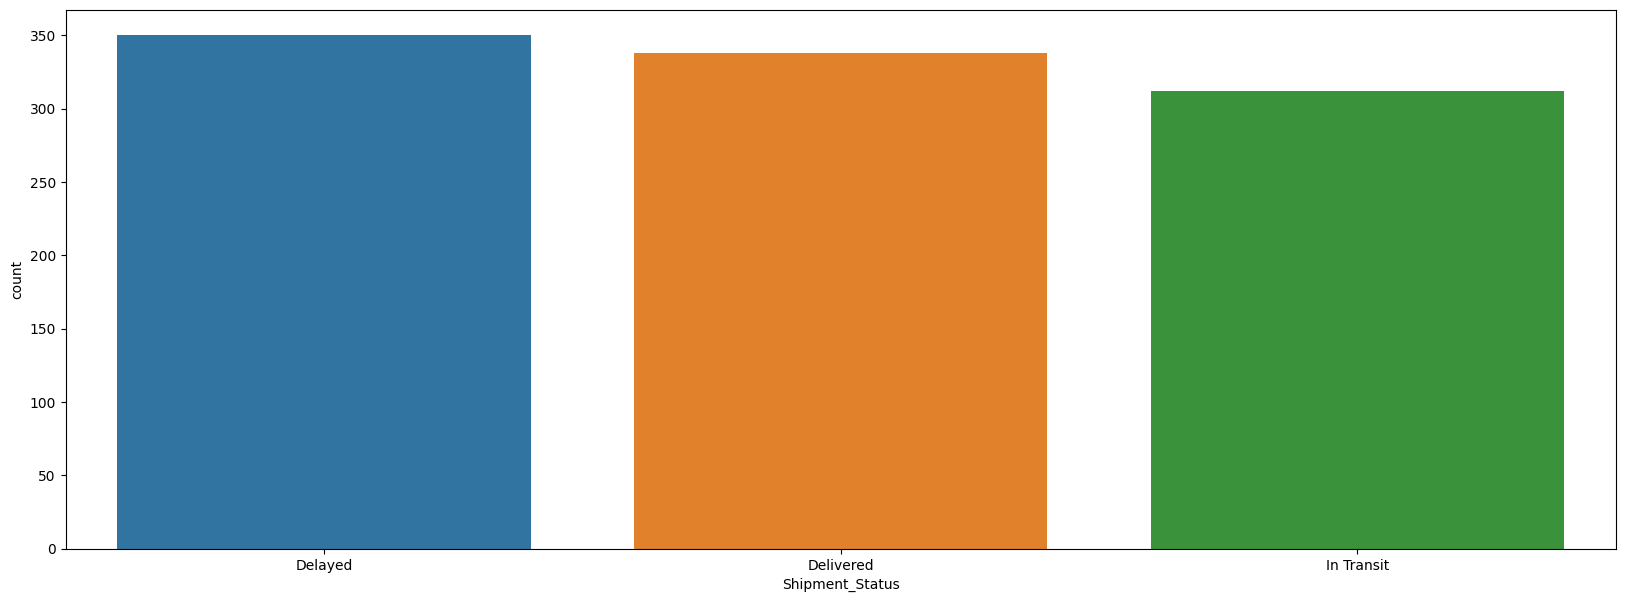

In [29]:
sns.barplot((df[['Shipment_Status']].value_counts()).reset_index(),x='Shipment_Status',hue='Shipment_Status',y='count')

In [30]:
((df[['Shipment_Status']].value_counts())/sum(df[['Shipment_Status']].value_counts())*100).reset_index()

,Shipment_Status,count
0,Delayed,35.0
1,Delivered,33.8
2,In Transit,31.2


# global shipment statues overview

* 35% of the blobal shipment was delayed 33.8% was delivered and 31.2% was in transit

the delayed had the top percentage the problem of the company is shipment delayed


In [31]:
pd.crosstab(
    df['Shipment_Status'],
    df['Logistics_Delay_Reason'],
    normalize='index'
)*100

Logistics_Delay_Reason,Mechanical Failure,No reason,Traffic,Weather
Shipment_Status,,,,
Delayed,24.000000,26.571429,21.428571,28.000000
Delivered,24.852071,24.260355,26.627219,24.260355
In Transit,21.153846,28.205128,22.756410,27.884615


###logistics delay reason

* globaly 28% of the dealyed was coused by the weather, 26.67% of the delayed didn't have a reason
and 24% caused by the mechanical failure and 21.43% caused by the traffic

## Marchine learning

in this marchine learning we will be trying to predict the shipment status , we will be using logistic regresion

In [32]:
from sklearn.model_selection import train_test_split

In [98]:
train_df,r_df=train_test_split(df,test_size=0.5,random_state=42)
val_df,test_df=train_test_split(r_df,test_size=0.5,random_state=42)

In [99]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(500, 18)
(250, 18)
(250, 18)


In [100]:
# inputs and targets creation
inputs=['Asset_ID', 'Latitude', 'Longitude', 'Inventory_Level',
        'Temperature', 'Humidity', 'Traffic_Status',
        'User_Transaction_Amount', 'User_Purchase_Frequency',
        'Asset_Utilization','Waiting_Time']
targets='Logistics_Delay_Reason'

In [101]:
df.columns

Index(['Timestamp', 'Asset_ID', 'Latitude', 'Longitude', 'Inventory_Level',
       'Shipment_Status', 'Temperature', 'Humidity', 'Traffic_Status',
       'Waiting_Time', 'User_Transaction_Amount', 'User_Purchase_Frequency',
       'Logistics_Delay_Reason', 'Asset_Utilization', 'Demand_Forecast',
       'Logistics_Delay', 'Date', 'Month'],
      dtype='object')

In [102]:
train_inputs=train_df[inputs].copy()
train_targets=train_df[targets].copy()
val_inputs=val_df[inputs].copy()
val_targets=val_df[targets].copy()
test_inputs=test_df[inputs].copy()
test_targets=test_df[targets].copy()

#### data preprocessing

In [103]:
numerical_col=train_inputs.select_dtypes(include=np.number).columns.tolist()
category_col=train_inputs.select_dtypes('object').columns.tolist()

In [104]:
## imputing numeric values
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy='mean').fit(train_inputs[numerical_col])
train_inputs[numerical_col]=imputer.transform(train_inputs[numerical_col])
val_inputs[numerical_col]=imputer.transform(val_inputs[numerical_col])
test_inputs[numerical_col]=imputer.transform(test_inputs[numerical_col])

In [105]:
## scaling numerical value
from sklearn.preprocessing import  MinMaxScaler
scaler=MinMaxScaler().fit(train_inputs[numerical_col])
train_inputs[numerical_col]=scaler.transform(train_inputs[numerical_col])
val_inputs[numerical_col]=scaler.transform(val_inputs[numerical_col])
test_inputs[numerical_col]=scaler.transform(test_inputs[numerical_col])

In [106]:
## Encoding categorical cols
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(sparse_output=False,handle_unknown='ignore').fit(train_df[category_col])
encoded_col=list(encoder.get_feature_names_out(category_col))
train_inputs[encoded_col]=encoder.transform(train_inputs[category_col])
val_inputs[encoded_col]=encoder.transform(val_inputs[category_col])
test_inputs[encoded_col]=encoder.transform(test_inputs[category_col])


In [107]:
x_train=train_inputs[encoded_col + numerical_col]
x_val=val_inputs[encoded_col + numerical_col]
x_test=test_inputs[encoded_col + numerical_col]

In [156]:
# let start predicting
from sklearn.metrics import log_loss,f1_score,recall_score,precision_score
from sklearn.linear_model import LogisticRegression
log=LogisticRegression(random_state=42).fit(x_train,train_targets)
train_prob=log.predict_proba(x_train)
train_preds=log.predict(x_train)
log_loss(train_targets,train_prob)

1.3092179721703832

In [109]:
f1_score(train_targets,train_preds,average='weighted')

0.3743293787163484

In [110]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
param={'max_depth':[2,3,5,6,7,8],
       'min_samples_split':[2,4,6,8]
       }
des_tree=DecisionTreeClassifier(random_state=42)

In [111]:
grid1=GridSearchCV(des_tree,param).fit(x_train,train_targets)

In [112]:
grid1.best_estimator_

DecisionTreeClassifier(max_depth=2, random_state=42)

In [113]:
best_model_tree=grid1.best_estimator_
train_preds2=best_model_tree.predict(x_train)
train_prob2=best_model_tree.predict_proba(x_train)

In [114]:
log_loss(train_targets,train_prob2)

1.347477920034121

In [115]:
f1_score(train_targets,train_preds2,average='weighted')

0.2136977303107204

In [116]:
from sklearn.tree import plot_tree,export_text
import warnings
warnings.filterwarnings('ignore')

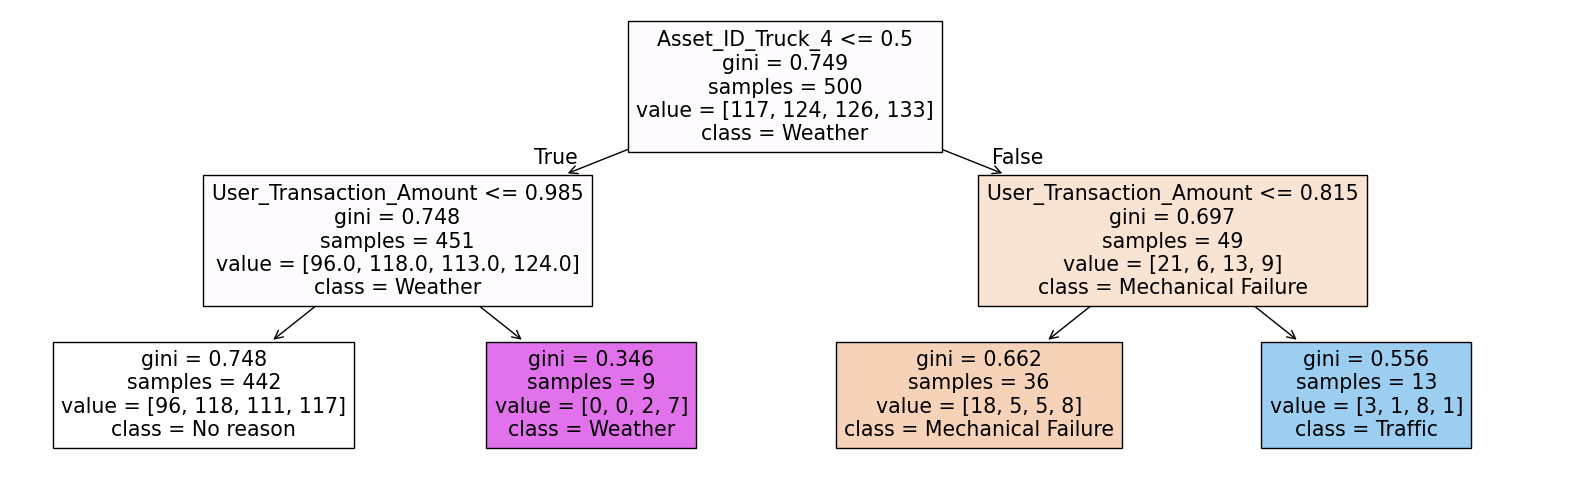

In [117]:
plot_tree(best_model_tree,feature_names=x_train.columns,filled=True,class_names=best_model_tree.classes_)
plt.rcParams['figure.figsize']=(20,81)

plt.show()

In [118]:
importances_tree=pd.DataFrame({
    'feature': x_train.columns,
    'importance':best_model_tree.feature_importances_
}).sort_values('importance',ascending=False)

In [119]:
importances_tree.head(10)

,feature,importance
18,User_Transaction_Amount,0.662972
4,Asset_ID_Truck_4,0.337028
1,Asset_ID_Truck_10,0.000000
2,Asset_ID_Truck_2,0.000000
3,Asset_ID_Truck_3,0.000000
0,Asset_ID_Truck_1,0.000000
5,Asset_ID_Truck_5,0.000000
6,Asset_ID_Truck_6,0.000000
8,Asset_ID_Truck_8,0.000000
7,Asset_ID_Truck_7,0.000000


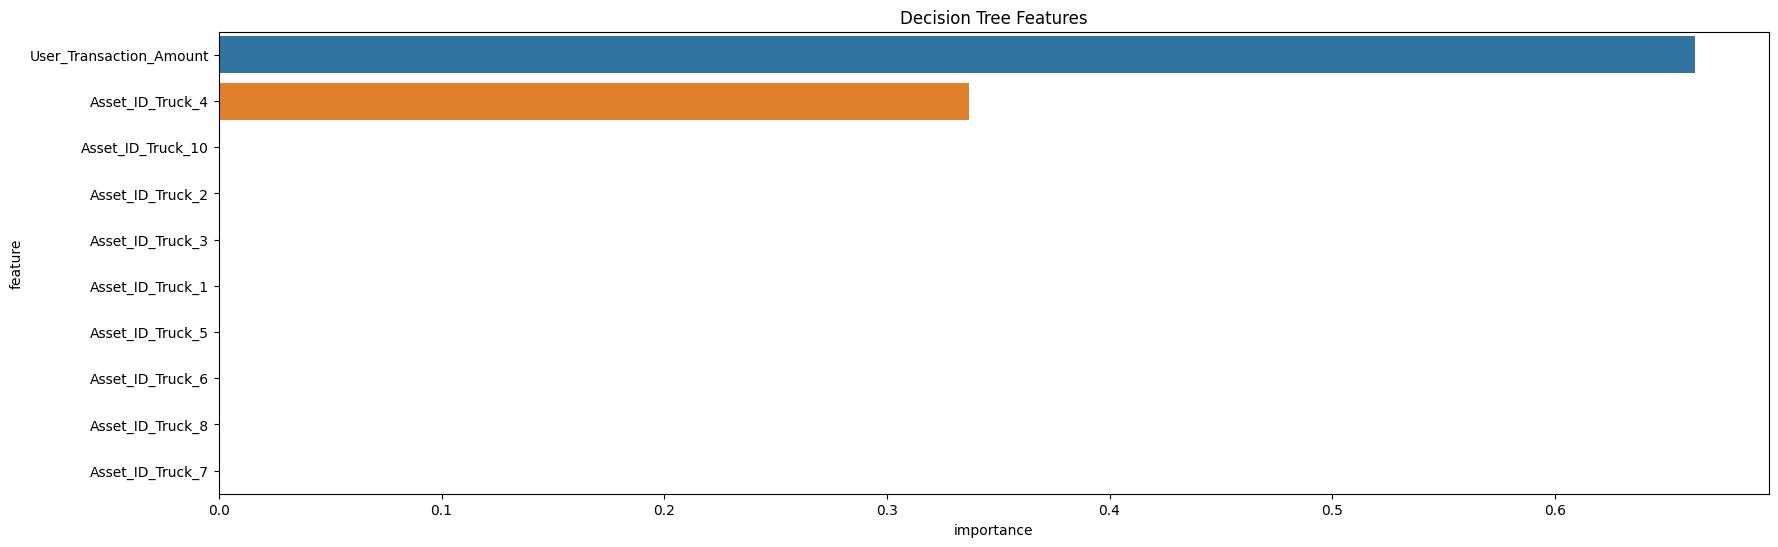

In [154]:
sns.barplot(importances_tree.head(10),x='importance',y='feature',hue='feature')
plt.rcParams['figure.figsize']=(20,7)
plt.title('Decision Tree Features')
plt.show()

In [121]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
random=RandomForestClassifier(random_state=42)

In [122]:
params2={
    'n_estimators':[100,200,300,400,500],
    'criterion':["gini", "entropy", "log_loss"],
    'min_samples_split':[2,4,6,7,8],
    'max_depth':[2,4,6,8,10,12]
}

In [123]:
R_search1=RandomizedSearchCV(random,params2,n_jobs=-1).fit(x_train,train_targets)

In [124]:
R_search1.best_estimator_

RandomForestClassifier(criterion='entropy', max_depth=4, min_samples_split=7,
                       random_state=42)

In [125]:
randm_best_model=R_search1.best_estimator_
train_preds3=randm_best_model.predict(x_train)
train_prob3=randm_best_model.predict_proba(x_train)

In [126]:
log_loss(train_targets,train_prob3)

1.236930899585283

In [127]:
f1_score(train_targets,train_preds3,average='weighted')

0.7156830188679246

In [128]:
importances_random=pd.DataFrame({
    'feature':x_train.columns,
    'importances':randm_best_model.feature_importances_
}).sort_values('importances',ascending=False)

In [129]:
importances_random.head(10)

,feature,importances
18,User_Transaction_Amount,0.120825
15,Inventory_Level,0.106018
16,Temperature,0.100199
17,Humidity,0.095259
13,Latitude,0.091090
20,Asset_Utilization,0.090735
14,Longitude,0.083765
21,Waiting_Time,0.076411
19,User_Purchase_Frequency,0.054700
4,Asset_ID_Truck_4,0.041462


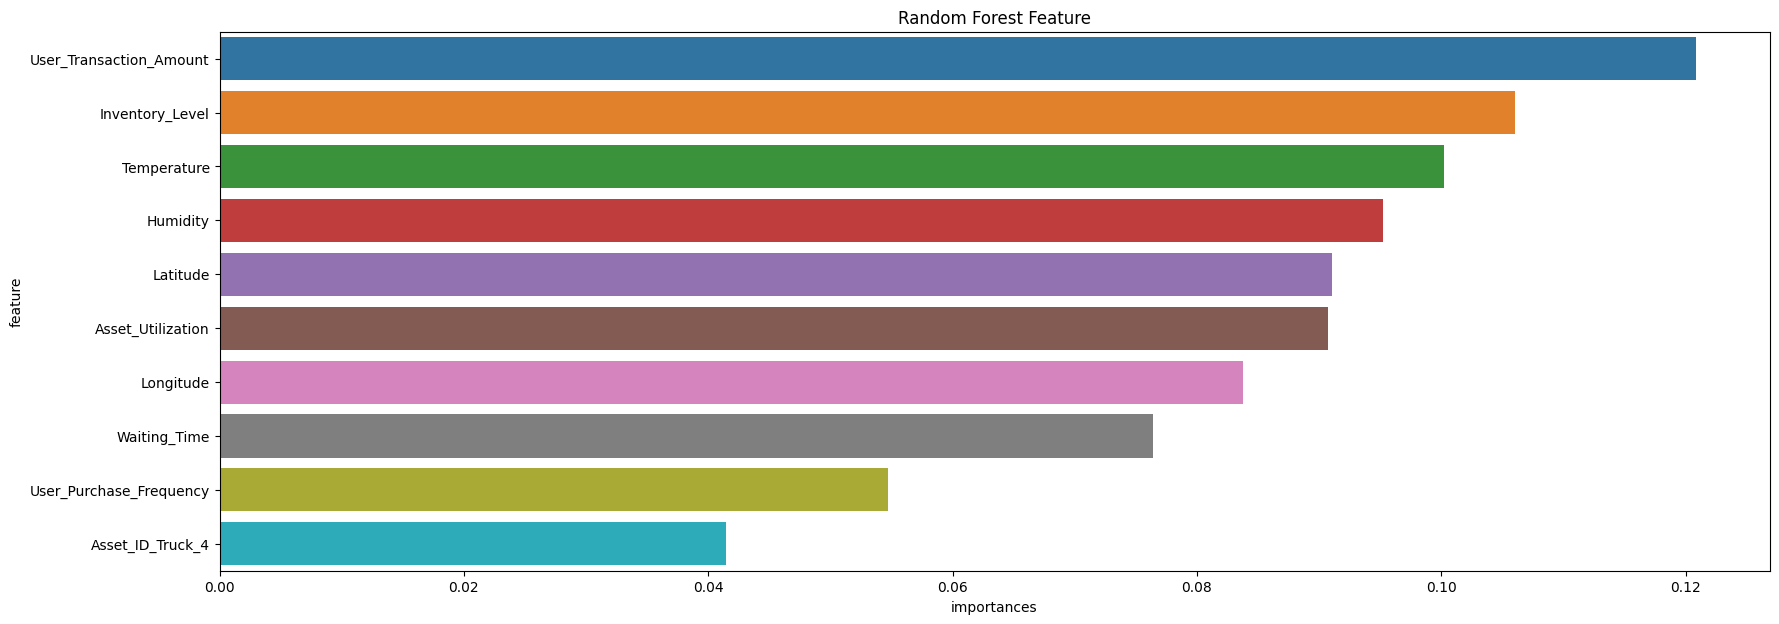

In [130]:
sns.barplot(importances_random.head(10),x='importances',y='feature',hue='feature')
plt.title('Random Forest Feature')
plt.rcParams['figure.figsize']=(20,6)
plt.show()

In [131]:
from xgboost import XGBClassifier
xgb=XGBClassifier(random_state=42)

In [132]:
target_nb={
    'No reason':0,'Weather':1,'Traffic':2,'Mechanical Failure':3
}

In [133]:
df.Logistics_Delay_Reason.unique()

array(['No reason', 'Weather', 'Traffic', 'Mechanical Failure'],
      dtype=object)

In [134]:
train_xb_targets=train_targets.map(target_nb)
val_xb_targets=val_targets.map(target_nb)
test_xb_targets=test_targets.map(target_nb)

In [135]:
train_targets.unique()

array(['Traffic', 'No reason', 'Mechanical Failure', 'Weather'],
      dtype=object)

In [136]:
param={
    'n_estimators':[100,50,200,20,400,300],
    'max_depth':[2,6,8,12,10],
    'learning_rate':[0.01,0.1,1.0,1.1,1.2],

}

In [137]:
R_search2=RandomizedSearchCV(xgb,param,n_jobs=-1).fit(x_train,train_xb_targets)

In [138]:
xgb_model=R_search2.best_estimator_

In [139]:
train_preds4=xgb_model.predict(x_train)
train_proba4=xgb_model.predict_proba(x_train)

In [140]:
log_loss(train_xb_targets,train_proba4)

1.280840553250337

In [141]:
f1_score(train_xb_targets,train_preds4,average='weighted')

0.4719899679068109

In [142]:
# xgb metric
print('log_loss:',log_loss(train_xb_targets,train_proba4))
print('f1_score',f1_score(train_xb_targets,train_preds4,average='weighted'))

log_loss: 1.280840553250337
f1_score 0.4719899679068109


In [143]:
# decision tree metrics
print('log_loss:',log_loss(train_targets,train_prob2))
print('f1_score',f1_score(train_targets,train_preds2,average='weighted'))

log_loss: 1.347477920034121
f1_score 0.2136977303107204


In [144]:
#  random forest metrics
print('log_loss:',log_loss(train_targets,train_prob3))
print('f1_score',f1_score(train_targets,train_preds3,average='weighted'))

log_loss: 1.236930899585283
f1_score 0.7156830188679246


In [145]:
# logistic regressor metrics
print('log_loss:',log_loss(train_targets,train_prob))
print('f1_score',f1_score(train_targets,train_preds,average='weighted'))

log_loss: 1.3092179721703832
f1_score 0.3743293787163484


# validation testing

In [146]:
# xbgb
val_preds1=xgb_model.predict(x_val)
val_proba=xgb_model.predict_proba(x_val)
print('log_loss:',log_loss(val_xb_targets,val_proba))
print('f1_score',f1_score(val_xb_targets,val_preds1,average='weighted'))

log_loss: 1.3994104686802198
f1_score 0.23339851124919914


In [147]:
# random forest
val_preds2=randm_best_model.predict(x_val)
val_proba2=randm_best_model.predict_proba(x_val)
print('log_loss:',log_loss(val_targets,val_proba2))
print('f1_score',f1_score(val_targets,val_preds2,average='weighted'))

log_loss: 1.3846066114737843
f1_score 0.2656438068303337


In [148]:
# decision tree
val_preds3=best_model_tree.predict(x_val)
val_proba3=best_model_tree.predict_proba(x_val)
print('log_loss:',log_loss(val_targets,val_proba3))
print('f1_score',f1_score(val_targets,val_preds3,average='weighted'))

log_loss: 1.411211066909133
f1_score 0.14861109575033027


In [149]:
# logistics regression
val_preds4=log.predict(x_val)
val_proba4=log.predict_proba(x_val)
print('log_loss:',log_loss(val_targets,val_proba4))
print('f1_score',f1_score(val_targets,val_preds4,average='weighted'))

log_loss: 1.4624815551329837
f1_score 0.23969627019692358


# test testing

In [150]:
# xbgb
test_preds1=xgb_model.predict(x_test)
test_proba=xgb_model.predict_proba(x_test)
print('log_loss:',log_loss(test_xb_targets,test_proba))
print('f1_score',f1_score(test_xb_targets,test_preds1,average='weighted'))

log_loss: 1.3902321917009606
f1_score 0.2834976431180174


In [151]:
# random forest
test_preds2=randm_best_model.predict(x_test)
test_proba2=randm_best_model.predict_proba(x_test)
print('log_loss:',log_loss(test_targets,test_proba2))
print('f1_score',f1_score(test_targets,test_preds2,average='weighted'))

log_loss: 1.3826242291639437
f1_score 0.2462782783958046


In [152]:
# decision tree
test_preds3=best_model_tree.predict(x_test)
test_proba3=best_model_tree.predict_proba(x_test)
print('log_loss:',log_loss(test_targets,test_proba3))
print('f1_score',f1_score(test_targets,test_preds3,average='weighted'))

log_loss: 1.822471163153236
f1_score 0.17458955162484574


In [153]:
# logistics regression
test_preds4=log.predict(x_test)
test_proba4=log.predict_proba(x_test)
print('log_loss:',log_loss(test_targets,test_proba4))
print('f1_score',f1_score(test_targets,test_preds4,average='weighted'))

log_loss: 1.4150895592693309
f1_score 0.2723632353713023
